<a href="https://colab.research.google.com/github/rohanwillcode/Soccer-Performance-Analysis/blob/main/soccer_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter: **Soccer Pass Network and Performance Analysis**

## **1. Introduction**

In the world of soccer, performance is no longer judged by goals and assists alone. Modern analytics allows us to dissect the **structure of possession**, **player involvement**, and **team strategy** through detailed event data. Among the many tools available, **pass network analysis** has emerged as a powerful technique for revealing how teams build attacks, control tempo, and coordinate movements across the pitch.

By treating players as **nodes** and passes as **directed, weighted edges**, we can model the entire game as a network—uncovering patterns invisible to the naked eye. This approach not only enriches tactical understanding but also offers a quantitative framework for comparing teams and players.

In this chapter, we apply network science to data from the **2022 FIFA World Cup Final (Argentina vs France)** using `statsbombpy`. You will learn how to construct passing networks, compute key network metrics, and draw tactical insights from visual and statistical analysis.


### What You'll Learn

- How to load and preprocess real-world soccer event data using `statsbombpy`.
- How to construct **directed, weighted graphs** of team passing networks.
- How to compute and interpret key **network metrics**:
  - **Edge density**: How connected the team is.
  - **Clustering coefficient**: Local passing triangles.
  - **Betweenness centrality**: Influence on passing routes.
  - **Closeness centrality**: Access to teammates.
- How to **visualize passing networks** on a soccer pitch.
- How to **compare tactical structures** of both teams through metrics and visuals.

This analysis does not use machine learning. Instead, we focus on **descriptive statistics and network theory** to answer a fundamental question:

> **How do team passing structures reflect tactical intent and match performance?**

By the end of this chapter, you will be able to construct similar pass network visualizations and metrics for any match, making this a highly transferable skill in the field of sports analytics.

---

### 1.1 **History of Analysis in Soccer :**

Football analysis has evolved drastically over time—from intuition-based judgments to advanced, data-driven approaches. This shift mirrors the growth of technology, competition, and the demand for deeper tactical insights.

In the early days, **coaches and scouts relied on personal observation**, handwritten notes, and basic match stats. Tactical discussions were mostly visual and informal, often based on match footage or chalkboards.

The transformation began in the **1990s and 2000s** with tools like ProZone and OPTA, allowing clubs to:

- Track player actions and events systematically.
- Quantify passes, shots, tackles, and more.
- Compare player performances across matches.

By the 2010s, **analytics matured further**, with tools for positional tracking, expected goals (xG), and even spatial control analysis. These enabled a clearer view of **team shape, efficiency, and tactical execution**.

Today, top teams use **dedicated analytics departments**. Modern methods incorporate **network science**, **machine learning**, and **visualizations**—giving coaches sharper insights and fans a new way to understand the game.

Pass network analysis, the focus of this chapter, is one such tool that blends visual storytelling with tactical depth.

### 1.2 **Importance of Tactical Analysis in Soccer :**

In modern football, the margin between victory and defeat often hinges on strategic decisions, positioning, and team coordination—not just individual skill. As the game becomes faster and more data-driven, **tactical analysis** plays a vital role in evaluating how well a team executes its game plan across different phases of play.

One key element of tactical analysis is understanding **how players interact and move the ball collectively**. This is especially important for coaches and analysts aiming to:

- 🧠 **Decode the opponent's strategy** and anticipate their build-up patterns.
- 📊 **Identify key players** who influence transitions, maintain possession, or initiate attacks.
- 🎯 **Optimize team formations and roles** by analyzing strengths and weaknesses in ball circulation.

Beyond the professional sphere, tactical analysis also empowers fans, commentators, and students of the game to interpret matches with greater depth. It transforms the sport from just a sequence of actions into a rich, interconnected system of decisions and behaviors.

In this chapter, we explore one of the most powerful tools in tactical analysis: **pass network modeling** — a technique that transforms on-field passes into measurable, visual structures to reveal the underlying dynamics of team play.

---


## **2. Data Collection**

To begin our analysis, we need to retrieve detailed event-level data for the 2022 FIFA World Cup Final between Argentina and France. We use the `statsbombpy` Python library, which provides free access to StatsBomb’s open event data.

This data includes every on-ball action recorded during the match — from passes and shots to fouls and substitutions. Specifically, we will extract match metadata and the complete event stream for this final, which forms the foundation for our pass network construction and tactical evaluation.

### What This Step Includes:
- Installing and importing required libraries.
- Fetching all World Cup 2022 matches using `statsbombpy`.
- Locating the Final by team names and match date.
- Loading the complete event data for the selected match.
- Verifying that passes and player information are well-represented.

This step ensures that we have all the necessary raw information to construct team-level pass networks and begin uncovering deeper tactical patterns.



In [ ]:
# 1. Install required packages
%pip install statsbombpy networkx

In [ ]:
# 2. Suppress StatsBomb NoAuth warnings
import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings("ignore", category=NoAuthWarning)

# 3. Imports
import pandas as pd
from statsbombpy import sb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# 4. Identify FIFA World Cup seasons
comps = sb.competitions()
wc = comps[comps.competition_name.str.contains("World Cup", regex=False)]
wc2022 = wc[wc.season_name.str.contains("2022", regex=False)].iloc[0]
comp_id, season_id = wc2022.competition_id, wc2022.season_id
print(f"Using competition_id={comp_id}, season_id={season_id} for {wc2022.season_name}")

# 5. Fetch matches for the 2022 World Cup
matches = sb.matches(competition_id=comp_id, season_id=season_id)

# 6. Select the Final by date (2022-12-18)
final_match = matches[matches.match_date == "2022-12-18"].iloc[0]
print(f"Final match: {final_match.home_team} vs {final_match.away_team} on {final_match.match_date}")

# 7. Load event data for the Final match
events = sb.events(match_id=final_match.match_id)

# 8. Preview event data
events.head()

Using competition_id=43, season_id=106 for 2022
Final match: Argentina vs France on 2022-12-18


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Argentina,779,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",France,771,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN


**Interpretation of Output**

- We successfully accessed detailed **event-level data** for the **2022 FIFA World Cup Final** between **Argentina** and **France**, using the `statsbombpy` API.
- The `events.head()` preview confirms a structured `pandas` DataFrame containing rich information like:
  - Event type (e.g., Pass, Shot).
  - Involved player and team.
  - Pitch location and event outcome.
- This dataset provides a solid foundation for analyzing passing behavior and team tactics.

---

Next, we’ll perform **Exploratory Data Analysis (EDA)** to examine event types and understand the structure before building pass networks.

---

## **3. Exploratory Data Analysis**

Before diving into network modeling, it's essential to explore the structure and content of the event data collected from the 2022 FIFA World Cup Final. This step helps us understand the types of actions recorded, verify data completeness, and confirm that the necessary information (like player names, teams, pass locations, and outcomes) is present. By previewing columns, inspecting event types, and reviewing the number of pass events, we ensure that the dataset is suitable for constructing meaningful pass networks and performing tactical analysis.

In the following subsections, we’ll:

* Examine the structure and preview the contents of the dataset.

* Analyze the frequency and distribution of key event types.

---

### 3.1 **Understanding the Event Data Structure :**

The event data for a match contains a wide range of actions (passes, shots, duels, etc.), each stored as a row in a large DataFrame. Each row includes dozens of columns capturing everything from player identity to event outcome and pitch location.

The following code block will:
- Display all available column names, so you know what information can be used for analysis.
- Preview the first 10 rows to see how the data is structured and spot missing or unusual entries.
- Count all types of events in the `"type"` column, so you can confirm the presence and frequency of passes and other relevant actions.


In [ ]:
# Show all column names and first rows to inspect structure
print("Columns:", events.columns.tolist())
print(events.head(10))

# Try to extract event types, depending on column name
if 'type_name' in events.columns:
    print(events['type_name'].value_counts(dropna=False))
elif 'type' in events.columns:
    # The 'type' column may be a dictionary per row
    print(events['type'].apply(lambda x: x.get('name') if isinstance(x, dict) else x).value_counts(dropna=False))
else:
    print("Could not find event type column.")

Columns: ['50_50', 'bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_other', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_committed_penalty', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_deflected', 'pass_end_location', 'pass_goal_assi

**Interpretation of Output**

* The dataset contains a rich variety of columns (94 in total), covering detailed information about each match event — including player names, actions, timestamps, and locations.

* The first 10 rows typically include events like "Starting XI" or "Half Start", which initialize the match but do not involve on-field play. It’s normal for these to contain missing or non-relevant values.

* The `"type"` column categorizes every row by event type. The frequency count reveals:
  - **1263 Pass events**, which is more than enough to analyze team passing structure.
  - Other actions (Ball Receipt, Carry, Shot, Duel, Foul, etc.) are also well-represented, enabling future studies on different aspects of match play.

*  The presence of `"pass_recipient"`, `"player"`, `"location"`, `"team"`, and `"pass_length"` columns confirms we can extract all relevant details for pass network analysis.

---

**Conclusion:**  
The data is well-structured and complete. We are ready to filter and analyze pass events to begin constructing the pass networks.

---


## **4. Pass Network**

Now that our data is clean, structured, and ready for analysis, we move on to one of the most insightful areas in soccer analytics — pass network construction. This technique helps translate raw match events into meaningful patterns of play by modeling player interactions as a graph.

A pass network is a powerful tool that represents players as nodes and successful passes between them as directed, weighted edges. By doing so, we can analyze how the ball flows within a team, identify central figures in possession, and uncover tactical strategies embedded in passing behavior.

Why pass networks matter:

* Reveals internal structure of the team and player connectivity.

* Highlights influential players based on their involvement in pass exchanges.

* Provides a foundation for both visual and quantitative tactical analysis.

---

Let’s now explore what exactly a pass network is, and how it helps us decode a team’s playing style

---

### 4.1 **What is Pass Network :**

 A pass network is a graphical representation of a team’s ball movement, where players are modeled as nodes and the passes between them as edges. It transforms event data into a structured network, enabling both visual and mathematical interpretation of a team's style of play.

In this network:

* Nodes represent individual players on the field.

* Edges represent successful passes, drawn from the passer to the receiver.

* Edge weight indicates the frequency of passes between two players (more passes = thicker edge).

These networks are usually directed (from passer to recipient) and weighted (based on number of passes). When plotted on a pitch using players’ average pass positions, they provide a powerful visual summary of team shape, ball circulation, and key influencers during a match.

In essence, pass networks help us understand not just who is involved in the game, but how they connect.

### 4.2 **Building Team Pass Networks :**

Now that we've established the concept of pass networks, we move forward with the actual construction of team-wise networks using the event data.

 This process involves identifying how players interact through successful passes and modeling these relationships using graph theory. By converting raw event data into a structured network, we lay the groundwork for tactical and statistical insights.

We will:

1. Filter for completed passes only, ensuring only successful ball movements are counted.

2. Extract the passer, recipient, and team name from each pass event.

3. Group and count each unique (passer → recipient) combination to calculate the edge weights.

4. Build a networkx.DiGraph for each team, where:

In [ ]:
# 1. Filter for completed passes
completed_passes = events[(events['type'] == 'Pass') & (events['pass_outcome'].isna())].copy()

# 2. Extract passer, recipient, and team info
completed_passes['passer'] = completed_passes['player']
completed_passes['recipient'] = completed_passes['pass_recipient']
completed_passes['team'] = completed_passes['team']

# 3. Build a directed, weighted graph for each team
team_graphs = {}
for team in completed_passes['team'].unique():
    team_df = completed_passes[completed_passes['team'] == team]
    G = nx.DiGraph()
    players = pd.unique(team_df[['passer', 'recipient']].values.ravel('K'))
    G.add_nodes_from(players)
    # Edge weights: number of passes from passer to recipient
    pass_counts = team_df.groupby(['passer', 'recipient']).size()
    for (src, dst), count in pass_counts.items():
        G.add_edge(src, dst, weight=count)
    team_graphs[team] = G

# 4. Print graph statistics
for team, G in team_graphs.items():
    print(f"{team}: {G.number_of_nodes()} players, {G.number_of_edges()} pass links")

France: 17 players, 143 pass links
Argentina: 17 players, 129 pass links


**Interpretation of output**
The output reveals:

- **France:**  
  `17 players`, `143 pass links`  
  → France involved **17 unique players** (including substitutes) in their passing sequences and recorded **143 distinct passing connections** (directed from one player to another at least once).

- **Argentina:**  
  `17 players`, `129 pass links`  
  → Similarly, Argentina also used **17 players** and recorded **129 unique pass links** throughout the match.

**Conclusion:**
- The player count aligns with typical match involvement (11 starters + substitutes).
- The number of **pass links** shows the **density and variety** of passing interactions between players.
- France had **more diverse passing connections** than Argentina, which may indicate:
  - Broader ball distribution across teammates.
  - More dynamic or adaptive play structures.

With these networks constructed, we are now prepared to visualize the passing patterns and further explore the tactical approaches of each team.

---

## **5. Network Pass Visualization**

With our pass networks successfully constructed, the next step is to **visualize** them on a soccer pitch. Visualizing these networks helps us understand not only how frequently players connect with each other, but also where on the pitch these interactions typically occur.

In these visualizations:

- Each **node** represents a player, positioned by the **average location** from where they made passes.
- **Edges** are directed arrows between players, representing completed passes.
- **Edge thickness** reflects the **number of passes** between two players (i.e., connection strength).
- **Node size** corresponds to a player's total involvement (passes made + received).

This kind of visualization allows us to **identify team shape**, **key passing partnerships**, and **tactical roles** in a visually intuitive way.

> Now, let’s build and plot the pass networks for **France** and **Argentina** during the 2022 World Cup Final.


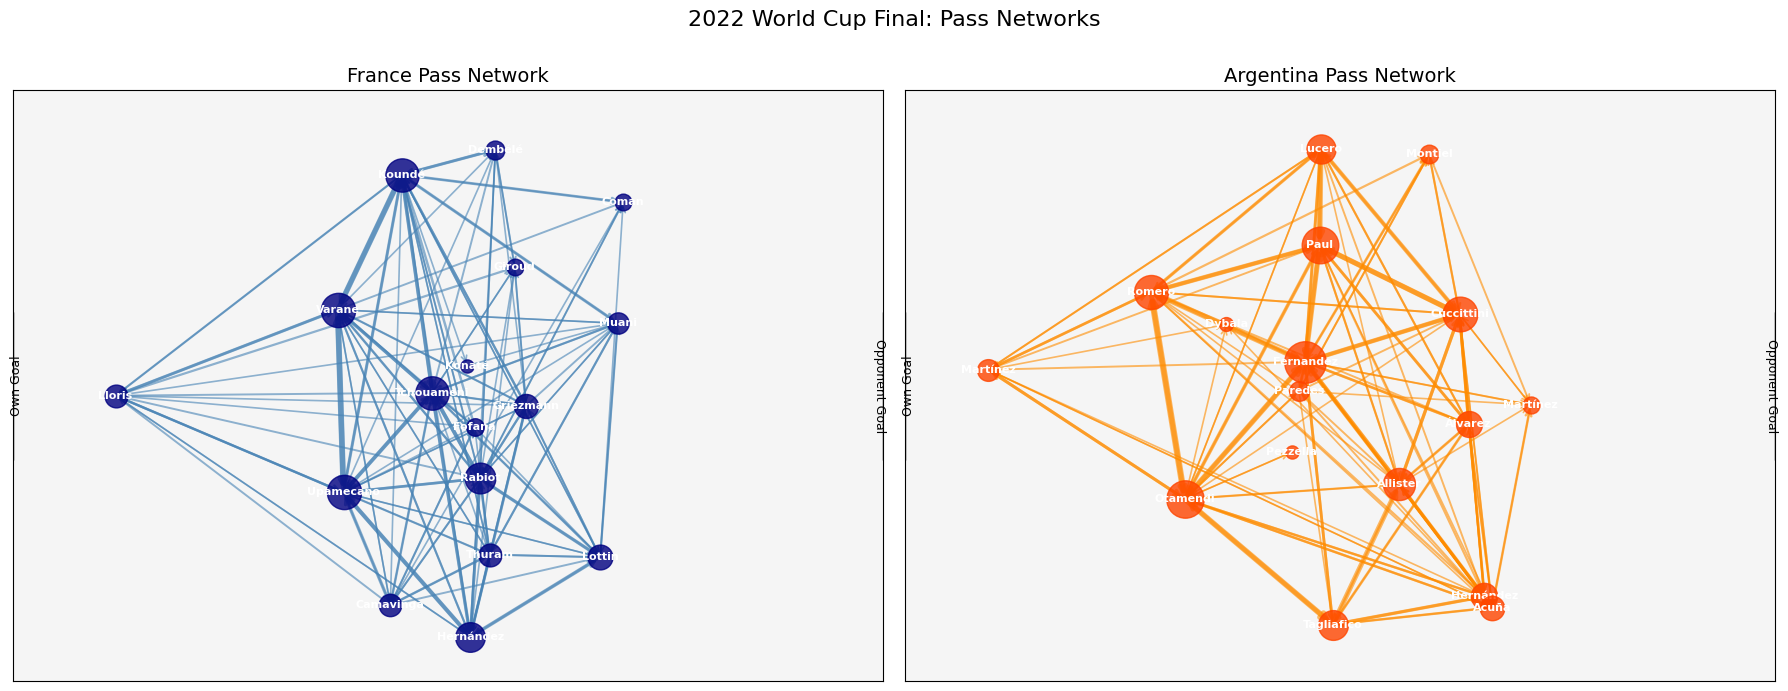

In [ ]:
def plot_pass_network(team_df, G, team_name, ax):
    # Calculate average pass starting location for each player
    avg_loc = (
        team_df.groupby('passer')['location']
        .apply(lambda locs: np.nanmean(np.vstack(locs.values), axis=0))
        .apply(pd.Series)
        .rename(columns={0: 'x', 1: 'y'})
    )

    # Calculate pass involvement for node size
    involvement = (
        team_df['passer'].value_counts() + team_df['recipient'].value_counts()
    ).groupby(level=0).sum()

    # Draw pitch
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_facecolor('whitesmoke')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{team_name} Pass Network", fontsize=14)

    # Draw goals (rectangles)
    goal_height = 20
    goal_width = 2
    # Left goal
    ax.add_patch(plt.Rectangle((-goal_width, (80 - goal_height) / 2), goal_width, goal_height,
                               edgecolor='black', facecolor='lightgray', zorder=0))
    ax.text(0.5, 40, 'Own Goal', fontsize=9, color='black', ha='center', va='center', rotation=90)
    # Right goal
    ax.add_patch(plt.Rectangle((120, (80 - goal_height) / 2), goal_width, goal_height,
                               edgecolor='black', facecolor='lightgray', zorder=0))
    ax.text(119.5, 40, 'Opponent Goal', fontsize=9, color='black', ha='center', va='center', rotation=270)

    # Draw edges
    for src, dst, data in G.edges(data=True):
        if src in avg_loc.index and dst in avg_loc.index:
            ax.annotate(
                '',
                xy=avg_loc.loc[dst],
                xytext=avg_loc.loc[src],
                arrowprops=dict(
                    arrowstyle="->",
                    lw=1 + data['weight'] * 0.2,
                    color='steelblue' if team_name == 'France' else 'darkorange',
                    alpha=0.6
                )
            )

    # Draw nodes
    for player in G.nodes:
        if player in avg_loc.index:
            ax.scatter(
                avg_loc.loc[player, 'x'], avg_loc.loc[player, 'y'],
                s=80 + 5 * involvement.get(player, 1),
                color='navy' if team_name == 'France' else 'orangered',
                alpha=0.8,
                zorder=3
            )
            ax.text(
                avg_loc.loc[player, 'x'], avg_loc.loc[player, 'y'],
                player.split()[-1], fontsize=8, ha='center', va='center',
                color='white', weight='bold'
            )

# Prepare side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, team in zip(axes, team_graphs.keys()):
    team_df = completed_passes[completed_passes['team'] == team]
    G = team_graphs[team]
    plot_pass_network(team_df, G, team, ax)

plt.suptitle("2022 World Cup Final: Pass Networks", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Interpretation of Pass Network Visualisations**

The pass network diagrams above visually summarize the structure and flow of each team's play during the 2022 World Cup Final:

- **Player Positioning:**  
  Nodes represent players and are placed according to their average pass starting locations. This helps us see which areas of the pitch each player operated in most frequently.

- **Node Size:**  
  Larger nodes correspond to players who were highly involved in the passing game—either making or receiving a high volume of passes.  
  Both teams have several prominent nodes in central and defensive midfield areas, indicating that play was often built through these positions.

- **Edge Thickness:**  
  Thicker edges indicate high-frequency passing connections between specific players. Dense clusters of thick edges suggest key passing partnerships and areas of the pitch where the ball was circulated most often.

- **Tactical Shape:**  
  - **France’s network** appears compact, with a high density of connections between defenders, midfielders, and some wide players. The network suggests an emphasis on ball circulation within the team, especially through central and deeper players.
  - **Argentina’s network** also shows a dense web of connections, but with some particularly strong passing links in central midfield and from defenders to midfielders. The pattern hints at progressive buildup play and frequent involvement of central playmakers.

- **General Insights:**  
  Both teams demonstrate well-connected passing structures, with very few isolated players. This reflects a collective approach to ball retention and progression up the pitch, which is common at the highest level of international soccer.

These visualizations make it clear which players were central to each team's tactics, and lay the foundation for further quantitative analysis of the networks’ properties.

---


## **6. Network Metrics**

To gain deeper insight into each team’s tactical structure beyond visuals, we now turn to network metrics. These metrics help quantify how effectively a team distributed the ball, involved players, and built passing structures during the match.

They reveal critical aspects of performance such as player influence, ball circulation efficiency, and structural cohesion — all of which are difficult to capture from raw statistics alone.

We’ll focus on the following key metrics:

* **Edge Density**: Measures how well-connected the passing network is.

* **Clustering Coefficient**: Reveals the presence of local passing triangles and team chemistry.

* **Betweenness Centrality**: Identifies key players acting as bridges between others.

* **Closeness Centrality**: Highlights how easily a player can reach teammates in the network.

These metrics provide a quantitative backbone to our visual observations, helping validate tactical behavior using network science.

### 6.1 **Edge Density :**

Edge density measures the proportion of actual passes (edges) in the network compared to all possible passes between players.

* It gives insight into team connectivity — how well players are linking with each other.

* A higher edge density suggests more frequent and distributed passing across the team.

* Useful to assess overall team cohesion and fluidity.

---

**Formula-**

Edge Density = (Number of Actual Edges) / (Number of Possible Edges)

For a directed graph with N nodes:
Possible Edges = N × (N - 1)

---

**Explanation:**
Edge density quantifies how connected the graph is. A higher density means more direct passing links between players.

### 6.2 **Clustering Coefficient :**


The clustering coefficient captures the extent to which players form passing triangles — small, tight-knit units.

* High clustering indicates good local cooperation, common in possession-based styles.

* It reflects tactical patterns like short-passing play and midfield control.

* Helps in identifying build-up structures and supportive passing options.

---

**Formula-**

Clustering Coefficient of Node v =
  (Number of Closed Triplets Connected to v) / (Number of All Possible Triplets Centered at v)

Average Clustering Coefficient = Mean of All Nodes’ Clustering Coefficients

---

**Explanation:**
This measures the degree to which players who receive passes from the same player also pass to each other — capturing triangular play or combinations.

### 6.3 **Betweenness Centrality :**

Betweenness centrality identifies players who frequently lie on the shortest paths between other players.

* High values indicate key intermediaries — often central midfielders or playmakers.

* These players act as connectors in the team’s passing structure.

* Helps assess influence on ball distribution and tempo.
---
**Formula-**

Betweenness Centrality of Node v =
  Σ (σ(s,t|v) / σ(s,t)) for all pairs (s, t), s ≠ t ≠ v

Where:
- σ(s,t) = Total number of shortest paths from s to t
- σ(s,t|v) = Number of those paths that pass through node v

---
**Explanation:**
It measures how often a player acts as a bridge along the shortest path in the passing network. High betweenness = strategic connector.

### 6.4 **Closeness Centrality :**

Closeness centrality shows how easily a player can reach every other teammate through passes.

* Players with high closeness are well-positioned and have efficient access to the full team.

* Reflects strategic placement — often associated with deep-lying playmakers or pivot players.

* Helps understand team shape and passing accessibility.

---
**Formula-**

Closeness Centrality of Node v =
  (N - 1) / Σ (shortest path distances from v to all other nodes)

---
**Explanation:**
Closeness measures how easily a player can reach every other teammate in the network via passes — indicating accessibility and centrality in the flow.

### 6.5 **Overall Tactical Insights from Network Metrics :**
Now that we have explored and understood the four key network metrics — Edge Density, Clustering Coefficient, Betweenness Centrality, and Closeness Centrality — it's time to summarize these measures for both teams in the 2022 World Cup Final.

The following code block computes and displays:

* Overall connectivity and structure of each team's pass network.

* Top 3 players in terms of Betweenness and Closeness Centrality to identify key influencers.

In [ ]:
# Prepare metrics for each team
metrics_summary = {}

for team, G in team_graphs.items():
    # Edge density: ratio of actual edges to possible edges
    density = nx.density(G)
    # Clustering coefficient: mean local clustering (undirected for triangles)
    clustering = nx.average_clustering(G.to_undirected(), weight='weight')
    # Betweenness centrality: importance as a connector
    betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
    # Closeness centrality: ease of reaching all other nodes
    closeness = nx.closeness_centrality(G, distance=lambda u, v, d: 1/d['weight'] if d['weight'] > 0 else float('inf'))

    # Top 3 players by betweenness and closeness
    top_betw = sorted(betweenness.items(), key=lambda x: -x[1])[:3]
    top_close = sorted(closeness.items(), key=lambda x: -x[1])[:3]

    metrics_summary[team] = {
        'density': density,
        'clustering': clustering,
        'betweenness': top_betw,
        'closeness': top_close,
    }

# Print out metrics for both teams
for team, m in metrics_summary.items():
    print(f"\n--- {team} ---")
    print(f"Edge density: {m['density']:.3f}")
    print(f"Clustering coefficient: {m['clustering']:.3f}")
    print("Top 3 Betweenness centrality (player, score):")
    for p, v in m['betweenness']:
        print(f"  {p}: {v:.3f}")
    print("Top 3 Closeness centrality (player, score):")
    for p, v in m['closeness']:
        print(f"  {p}: {v:.3f}")


--- France ---
Edge density: 0.526
Clustering coefficient: 0.118
Top 3 Betweenness centrality (player, score):
  Jules Koundé: 0.156
  Kylian Mbappé Lottin: 0.115
  Randal Kolo Muani: 0.102
Top 3 Closeness centrality (player, score):
  Dayotchanculle Upamecano: 2.501
  Aurélien Djani Tchouaméni: 2.371
  Raphaël Varane: 2.352

--- Argentina ---
Edge density: 0.474
Clustering coefficient: 0.124
Top 3 Betweenness centrality (player, score):
  Marcos Javier Acuña: 0.269
  Nicolás Hernán Otamendi: 0.194
  Lautaro Javier Martínez: 0.181
Top 3 Closeness centrality (player, score):
  Enzo Fernandez: 3.076
  Rodrigo Javier De Paul: 2.910
  Lionel Andrés Messi Cuccittini: 2.862


**Interpretation of Network Metrics**

| **Metric**                   | **France**                             | **Argentina**                            |
|-----------------------------|----------------------------------------|------------------------------------------|
| **Edge Density**            | 0.526                                  | 0.474                                    |
| **Clustering Coefficient**  | 0.118                                  | 0.124                                    |
| **Top 3 Betweenness Players** | Koundé (0.156)<br>Mbappé (0.115)<br>K. Muani (0.102) | Acuña (0.269)<br>Otamendi (0.194)<br>L. Martínez (0.181) |
| **Top 3 Closeness Players**   | Upamecano (2.501)<br>Tchouaméni (2.371)<br>Varane (2.352) | Enzo (3.076)<br>De Paul (2.910)<br>Messi (2.862)         |

---

1. France showed **slightly higher edge density**, suggesting more distributed passing.

2. Argentina had a **higher clustering coefficient**, indicating better local connectivity and short passing triangles.

3. **Argentina’s midfield** (Enzo, De Paul, Messi) dominated **closeness centrality**, reflecting strong central involvement.

4. France’s key connectors were mostly **defenders**, showing a more defensive or buildup-oriented network.


**Summary:**  
- Both teams exhibit dense, locally clustered passing networks, reflecting strong collective play.

- Tactical differences are visible in the roles of key connector players: Argentina’s defenders and central midfielders act as distribution hubs, while France shares this responsibility across defenders, midfielders, and forwards.

These insights offer an objective complement to the visual network analysis, and set the stage for a tactical comparison between the teams.

---

## **7. Tactical Comparison Between Teams**


Now that we've visualized and analyzed the passing networks for both teams, we can compare the tactical structures of **France** and **Argentina** during the 2022 FIFA World Cup Final using network metrics and key player roles.

---

#### **France – Tactical Overview**

- **High Network Density (0.526)**  
  Indicates frequent passing connections between players, supporting a flexible and adaptive style of play.

- **Key Connectors (Betweenness Centrality)**  
  - *Jules Koundé* (Right Back)  
  - *Kylian Mbappé* (Forward)  
  - *Randal Kolo Muani* (Forward)  
  These players played central roles in linking attacks and distributing the ball, reflecting France's focus on wide and forward channels.

- **Efficient Access to Teammates (Closeness Centrality)**  
  Midfielders and defenders showed high closeness, indicating that France built play efficiently from the back through central areas.

---

#### **Argentina – Tactical Overview**

- **Slightly Lower Density (0.474) but Higher Clustering**  
  Suggests a structured, short-passing style with more local combinations and tighter triangles.

- **Key Connectors (Betweenness Centrality)**  
  - *Marcos Acuña* (Left Back)  
  - *Nicolás Otamendi* (Center Back)  
  - *Lautaro Martínez* (Forward)  
  Emphasizes Argentina’s reliance on wide defenders and forwards in building attacks.

- **Midfield Dominance (Closeness Centrality)**  
  - *Enzo Fernández*, *Rodrigo De Paul*, and *Lionel Messi*  
  These players maintained strong central influence, connecting all zones of play and enabling ball circulation.

---

####  **Tactical Insights**

-  **Closeness Centrality** was highest for midfielders in both teams — highlighting their importance in maintaining structure and transitions.

-  **Argentina's higher clustering** reflects their emphasis on **controlled buildup** and **short-pass combinations**.
-  **France's higher density** suggests a **more direct and expansive style**, useful for quick transitions and counterattacks.

-  Network patterns align well with each team's broader strategy — **Argentina** with possession and buildup; **France** with width and pace.

---

By combining **graph theory metrics** with positional data, we gain a deeper understanding of each team's strategy — not just *what* happened, but *why* it worked.


## **8. Conclusion**

In this chapter, we explored how network science and Python can be applied to real soccer event data to uncover the hidden structure behind team tactics and performance.  
By building and analyzing pass networks for the 2022 FIFA World Cup Final, we demonstrated how:

- **Raw event data can be transformed into meaningful networks,** with players as nodes and completed passes as directed, weighted edges.

- **Network visualizations** help us intuitively understand team shape, main connectors, and patterns of ball circulation.

- **Key network metrics**—edge density, clustering coefficient, betweenness centrality, and closeness centrality, quantify team style and highlight the tactical roles of individual players.

- **Objective comparisons** can be made between teams, showing not only which players were most influential but also how tactical approaches shaped the match.

These methods are fundamental tools in modern sports analytics. They can be extended to any match, team, or competition, and are highly adaptable, enabling analysts, coaches, and fans to gain actionable insights from the flow of the game.

By understanding and applying pass network analysis, we have added a powerful technique to our sports analytics toolkit, one that blends mathematical rigor with tactical nuance.

---


## **9. Exercises**

Test your understanding of pass network analysis and practice extending these techniques with the following exercises:

1. **Explore Another Match:**  
   Use StatsBomb Open Data to load a different World Cup 2022 match (your choice). Construct pass networks for both teams and compare their network structures using the same metrics from this chapter.

2. **Key Player Comparison:**  
   For Argentina, identify the player with the highest betweenness centrality and plot all of their completed passes on the pitch. What does this reveal about their role?

3. **Network Metric Experiment:**  
   Calculate the clustering coefficient for only the starting XI (exclude substitutes). How does this compare to the whole-team clustering coefficient? What might this suggest about the influence of substitutes on network structure?

4. **Relate Pass Networks to Shots:**  
   Using the events data, filter for shot events and identify which players were most frequently involved in passing chains leading to shots. How do these players rank in centrality measures?

5. **Visualize a Subnetwork:**  
   Select three players from one team who form a triangle of frequent passes. Visualize their subnetwork and discuss how this local pattern fits into the team's overall tactical approach.

6. **Discussion:**  
   How might a team’s network structure change if they are losing and need to chase the game versus when they are defending a lead?  
   Suggest one new metric (not covered in this chapter) that could be useful for analyzing pass networks.

---

*Tip: All analyses can be done with `pandas`, `networkx`, and the plotting tools used in this chapter. Don’t hesitate to experiment with custom visualizations or deeper statistical summaries!*

---

**End of chapter**

---